In [1]:
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
import pickle
import json
import random
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
ptm_contact_dic = pickle.load(
    open("./data/cRDH.PTM.intra_interaction.summary.pkl", "rb")
)
seq_feature_dic = json.load(open("./data/cRDH.secondary_structure_anno.json", "r"))
MSA_MTR_df = pd.read_csv("./data/cRDH.MSA_MTR.obs_RGC.pred_MuRaL.csv")

In [3]:
for family, df in MSA_MTR_df.groupby("gene"):

    for anno_seq in ptm_contact_dic[family]:

        if anno_seq["label"] == "PTM":
            site_idx = [i for i, c in enumerate(anno_seq["color"]) if c != "azure"]
            MSA_MTR_df.loc[
                (MSA_MTR_df["gene"] == family) & (MSA_MTR_df["pos"].isin(site_idx)),
                "PTM",
            ] = 1

        if anno_seq["label"] in ["H2A", "H2B", "H3", "H4"]:
            site_idx = [i for i, c in enumerate(anno_seq["color"]) if c != "#FFF0ED"]
            MSA_MTR_df.loc[
                (MSA_MTR_df["gene"] == family) & (MSA_MTR_df["pos"].isin(site_idx)),
                "have_interact",
            ] = 1

# Fill NaN (no PTM/contact) with 0
MSA_MTR_df[["PTM", "have_interact"]] = MSA_MTR_df[["PTM", "have_interact"]].fillna(0)
# Exclude start codon
MSA_MTR_df = MSA_MTR_df[MSA_MTR_df["pos"] != 0]

In [4]:
MSA_MTR_df["domain"] = "Globular"
# Define domain
for gene, info in seq_feature_dic.items():
    for feature in info:
        if "tail" in feature["label"]:
            ss, es = feature["range"]
            MSA_MTR_df.loc[
                (MSA_MTR_df["gene"] == gene)
                & (MSA_MTR_df["pos"] >= ss)
                & (MSA_MTR_df["pos"] <= es),
                "domain",
            ] = "Tails"

In [5]:
MSA_MTR_df["PTM"] = MSA_MTR_df["PTM"].astype(int)
MSA_MTR_df["have_interact"] = MSA_MTR_df["have_interact"].astype(int)

# Create combination (PTM and interaction)
MSA_MTR_df["combo"] = (
    MSA_MTR_df["PTM"].map({0: "P0", 1: "P1"})
    + "_"
    + MSA_MTR_df["have_interact"].map({0: "I0", 1: "I1"})
)

p_values = {}
order = ["P0_I0", "P0_I1", "P1_I0", "P1_I1"]

for combo1, combo2 in combinations(order, 2):
    group1 = MSA_MTR_df[MSA_MTR_df["combo"] == combo1]["MTR"]
    group2 = MSA_MTR_df[MSA_MTR_df["combo"] == combo2]["MTR"]
    stat, pvalue = mannwhitneyu(
        group1.dropna().tolist(), group2.dropna().tolist()
    )
    p_values[f"{combo1} vs {combo2}"] = pvalue

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


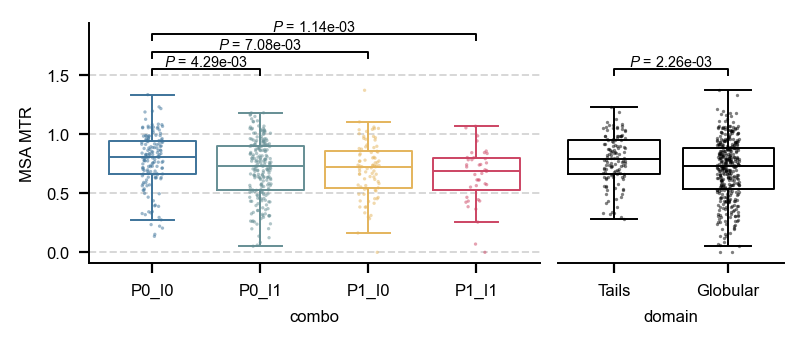

In [6]:
seed = 42
random.seed(seed)
np.random.seed(seed)

plt.rcParams["figure.dpi"] = 200
order = ["P0_I0", "P0_I1", "P1_I0", "P1_I1"]

fig, axes = plt.subplots(1, 2, figsize=(4, 1.7), width_ratios=[4, 2])
color_platte = ["#3d739a", "#658e94", "#e4b45c", "#cc4463"]
palette = {k: v for k, v in zip(order, color_platte)}

sns.boxplot(
    x="combo",
    y="MTR",
    data=MSA_MTR_df,
    order=order,
    ax=axes[0],
    hue="combo",
    hue_order=order,
    linewidth=0.7,
    showfliers=False,
    palette=palette,
    fill=False,
)
sns.stripplot(
    x="combo",
    y="MTR",
    data=MSA_MTR_df,
    order=order,
    ax=axes[0],
    hue="combo",
    hue_order=order,
    palette=palette,
    size=1.2,
    alpha=0.5,
)

# Annotate p-values on the plot (P0_I0 vs other)
base_y = 1.5
offset = 0.05
for i, (combo1, combo2) in enumerate(combinations(order, 2)):

    if combo1 != "P0_I0":
        continue
    combol2_index = order.index(combo2)
    pvalue = p_values[f"{combo1} vs {combo2}"]

    plot_y = base_y + i * 0.15
    axes[0].plot(
        [0, 0, combol2_index, combol2_index],
        [plot_y, plot_y + offset, plot_y + offset, plot_y],
        color="black",
        linewidth=0.7,
    )
    axes[0].text(
        (0 + combol2_index) / 2,
        plot_y + 0.05,
        f"$P$ = {pvalue:.2e}",
        ha="center",
        va="bottom",
        horizontalalignment="center",
        fontsize=5.2,
        transform=axes[0].transData,
    )

axes[0].set_ylabel("MSA MTR")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend_ = None

sns.boxplot(
    data=MSA_MTR_df,
    x="domain",
    y="MTR",
    fill=False,
    linewidth=0.7,
    color="black",
    ax=axes[1],
    showfliers=False,
)
sns.stripplot(
    data=MSA_MTR_df,
    x="domain",
    y="MTR",
    color="black",
    alpha=0.5,
    ax=axes[1],
    size=1.2,
)

axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_ylabel("MSA MTR")
# Calculate p-value
group_tail = MSA_MTR_df[MSA_MTR_df["domain"] == "Tails"]["MTR"]
group_glob = MSA_MTR_df[MSA_MTR_df["domain"] == "Globular"]["MTR"]
stat, pvalue = mannwhitneyu(
    group_tail.dropna().tolist(), group_glob.dropna().tolist()
)

axes[1].text(
    0.5,
    1.55,
    f"$P$ = {pvalue:.2e}",
    va="bottom",
    ha="center",
    fontsize=5.2,
)
axes[1].plot(
    [0, 0, 1, 1],
    [1.5, 1.55, 1.55, 1.5],
    color="black",
    linewidth=0.7,
)

ylim1 = axes[0].get_ylim()
axes[1].set_ylim(ylim1)
axes[1].yaxis.set_visible(False)
axes[1].spines["left"].set_visible(False)

for ax in axes:
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)

plt.tight_layout()